In [1]:
using Revise
using SSMCMain.ModifiedMiCRM.MinimalModelV2

┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Symbolics → SymbolicsForwardDiffExt
│  └─ Symbolics → SymbolicsPreallocationToolsExt
│ Precompilation will also be skipped for the following, which depend on the above cycle:
│   SSMC
│   MLSolver
└ @ Pkg.API.Precompilation ~/.julia/juliaup/julia-1.10.10+0.x64.linux.gnu/share/julia/stdlib/v1.10/Pkg/src/precompilation.jl:583
Precompiling packages...
  13366.7 ms  ✓ SSMCMain
  1 dependency successfully precompiled in 17 seconds. 540 already precompiled. 4 skipped due to circular dependency.


In [2]:
includet("../../scripts/mm_Kl_pds.jl")

In [3]:
using ProgressMeter
using ColorSchemes
using JLD2


In [4]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

In [115]:
logKs = range(-0.5, 3, 50)
lmin = 0.001
lmax = 1 - lmin
numls = 50

m = 1.
c = 1.
p = 0.1

ks = 10 .^ range(-6, 4, 10000)

leakxs = range(LeakageScale.ltox(lmin), LeakageScale.ltox(lmax), numls)
ls = LeakageScale.l.(leakxs)
Ks = 10 .^ logKs

# @time xx = do_Kl_pd_run(
#     logKs, ls,
#     m, c,
#     0., 1., p,
# );
@time pd_results = do_Kl_pd_run_scanning(
    ks,
    logKs, ls,
    m, c,
    0., 1., p;
    threshold=1e-6
);

  7.113406 seconds (209.60 M allocations: 27.276 GiB, 43.38% gc time)


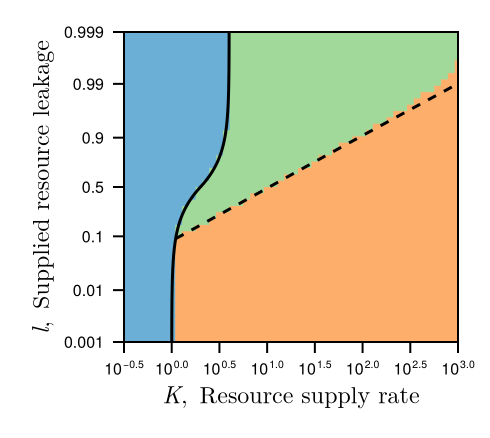

In [146]:
lticks=[0.001, 0.01, 0.1, 0.5, 0.9, 0.99, 0.999]

fig = Figure(;
    size=(double_col_width * 0.36, (double_col_width / golden_ratio) * 0.52),
)
ax = Axis(fig[1,1],
    yticks=(LeakageScale.ltox.(lticks), string.(lticks)),
    xscale=log10,
    xlabel=L"K,\enspace\text{Resource supply rate}",
    ylabel=L"l,\enspace\text{Supplied resource leakage}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)

heatmap!(ax, Ks, leakxs, PaperColors.mma_coloring_simple.(pd_results))

thr_leakxs = range(extrema(leakxs)..., 1000)
thr_ls = LeakageScale.l.(thr_leakxs)

extline_Ks = MinimalModelV2.fr_ext_line_K.(thr_ls, 1., 1.)
instabline_Ks = MinimalModelV2.fr_cor1_instab_line_K.(thr_ls, 1., 1., p)

lines!(ax, extline_Ks, thr_leakxs;
    color=:black,
)
lines!(ax, instabline_Ks, thr_leakxs;
    color=:black,
    linestyle=:dash,
)

xlims!(ax, extrema(Ks))
ylims!(ax, extrema(leakxs))

Makie.save("../../figures/fig2/pd.pdf", fig)

fig

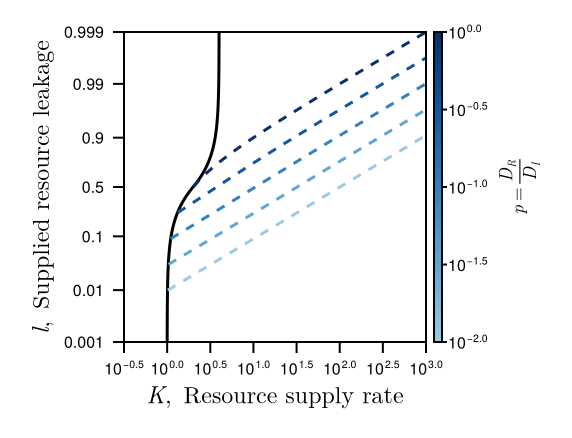

In [147]:
lticks=[0.001, 0.01, 0.1, 0.5, 0.9, 0.99, 0.999]

fig = Figure(;
    size=(double_col_width * 0.42, (double_col_width / golden_ratio) * 0.52),
)
ax = Axis(fig[1:2,1],
    yticks=(LeakageScale.ltox.(lticks), string.(lticks)),
    xscale=log10,
    xlabel=L"K,\enspace\text{Resource supply rate}",
    ylabel=L"l,\enspace\text{Supplied resource leakage}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
    xgridvisible=false,
    ygridvisible=false,
)

thr_leakxs = range(extrema(leakxs)..., 1000)
thr_ls = LeakageScale.l.(thr_leakxs)

extline_Ks = MinimalModelV2.fr_ext_line_K.(thr_ls, 1., 1.)

lines!(ax, extline_Ks, thr_leakxs;
    color=:black,
)

logps = range(0., -2, 5)
ps_cmap = cgrad(ColorSchemes.Blues[4:end])

lalal = extrema(logps)
logps_delta = lalal[2] - lalal[1]
logps_min = lalal[1]

for logp in logps
    p_ = 10 ^ logp
    instabline_Ks = MinimalModelV2.fr_cor1_instab_line_K.(thr_ls, 1., 1., p_)
    lines!(ax, instabline_Ks, thr_leakxs;
        color=get(ps_cmap, (logp - logps_min) / logps_delta),
        linestyle=:dash,
    )
end

xlims!(ax, extrema(Ks))
ylims!(ax, extrema(leakxs))

Colorbar(fig[1:2,2];
    limits=extrema(ps),
    colormap=ps_cmap,
    scale=log10,
    size=4,
    ticklabelsize=6fontsize_pt,
    labelsize=6fontsize_ltex_pt,
    label=L"p=\frac{D_R}{D_I}",
    ticksize=2,
    ticklabelpad=0,
)
# Label(fig[1,2], L"p=\frac{D_R}{D_I}";
#     rotation=pi/2,
# )

colgap!(fig.layout, 4.)
# rowsize!(fig.layout, 2, Relative(0.8))

Makie.save("../../figures/fig2/changing_p.pdf", fig)

fig

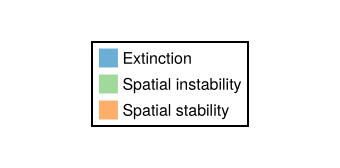

In [189]:
fig = Figure(;
    size=(double_col_width * 0.25, (double_col_width / golden_ratio) * 0.2),
)

Legend(fig[1,1],
    [
        MarkerElement(; color=PaperColors.extinct1(), marker=:rect, markersize=15),
        MarkerElement(; color=PaperColors.unstable1(), marker=:rect, markersize=15),
        MarkerElement(; color=PaperColors.stable1(), marker=:rect, markersize=15),
    ],
    [
        "Extinction",
        "Spatial instability",
        "Spatial stability",
    ];
    labelsize=6fontsize_pt,
    padding=(-2., 3., -2., -2.),
    rowgap=-7,
    patchlabelgap=-3,
)

Makie.save("../../figures/fig2/pd_legend.pdf", fig)

fig